Part B: Data Acquisition

5. Import datasets from different sources:

• Load CSV file using Pandas.
Parse a JSON file.
Connect to a SQL table and fetch records.
• Fetch data from an API (e.g., random user API or dummy REST API).

In [ ]:
import pandas as pd
import sqlite3

# Load CSV
df_csv = pd.read_csv("customer_purchases.csv")

# Load JSON
df_json = pd.read_json("customer_info.json")

# Load SQL
conn = sqlite3.connect("customer.db")
df_sql = pd.read_sql("SELECT * FROM subscriptions", conn)

# Load API
df_api = pd.read_json("api_data.json")

# Merge all datasets
df = df_csv.merge(df_json, on='Customer_ID') \
             .merge(df_sql, on='Customer_ID') \
             .merge(df_api, on='Customer_ID')


Part C: Data Understanding & Cleaning

6. Perform initial exploration:
• Use head(), info), describe() to explore.
Identify missing values and duplicates.

7. Apply data cleaning:
• Handle missing data (imputation or removal).
• Correct inconsistent data types.
• Drop irrelevant columns.

In [28]:
#First 5 rows
print(df.head(),"\n")

#information about data
print(df.info(),"\n")

#description of data
print(df.describe(),"\n")

#Missing values 
print(df.isna().sum(),"\n")

#duplicates 
print(df.duplicated(),"\n")

#there are no missing values in dataset so we the imputation or removal is not applied here and as well there are 0 duplicates

   Customer_ID  Income  Purchases  Age  Gender  Tenure  Churn  App_Usage_Hours
0            1   56631         39   56    Male       7      0                3
1            2   92991         14   46  Female       5      0                6
2            3   24014         31   32  Female       5      0                8
3            4   31093          5   25    Male       2      0                9
4            5   38070         35   38  Female       3      0                7 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Customer_ID      200 non-null    int64 
 1   Income           200 non-null    int64 
 2   Purchases        200 non-null    int64 
 3   Age              200 non-null    int64 
 4   Gender           200 non-null    object
 5   Tenure           200 non-null    int64 
 6   Churn            200 non-null    int64 
 7   App_Usage_

Part D: Exploratory Data Analysis (EDA)

8. Perform Univariate Analysis:
• Distribution plots of Age, Income, and Purchases.

9. Perform Bivariate Analysis:
• Relationship between Gender & Purchases.
Relationship between Income & Churn.

10. Perform Multivariate Analysis:
• Correlation heatmap of all numerical variables.
Pair plots to identify feature interactions.

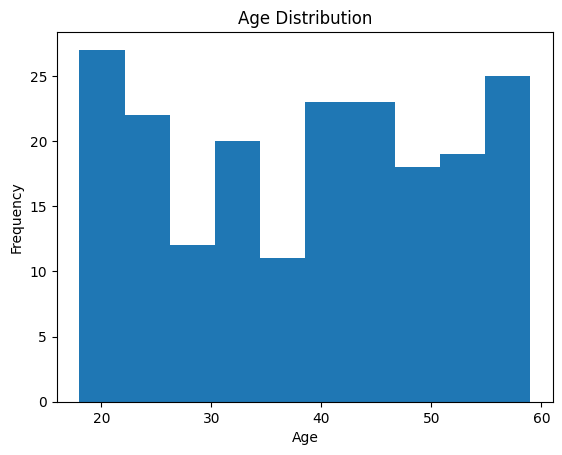

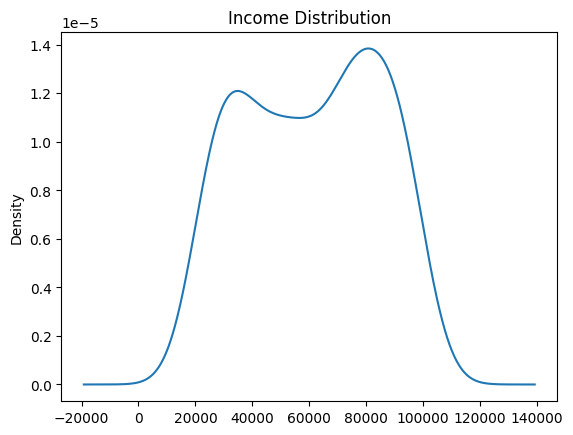

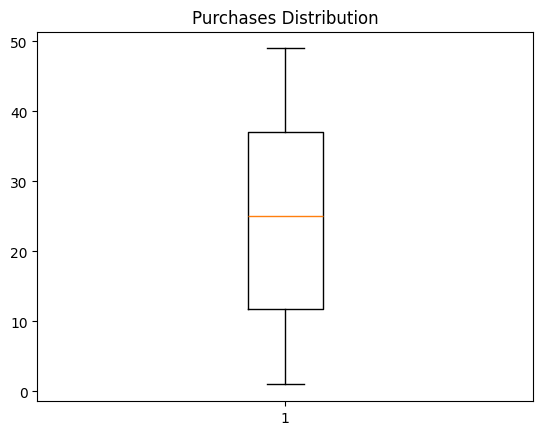

,Age,Income,Purchases
count,200.000000,200.000000,200.0000
mean,38.665000,60779.425000,24.4050
std,12.604648,23686.149172,14.4626
min,18.000000,20412.000000,1.0000
25%,27.750000,39114.500000,11.7500
50%,40.000000,61765.000000,25.0000
75%,49.250000,80741.500000,37.0000
max,59.000000,99634.000000,49.0000


In [52]:
import matplotlib.pyplot as plt

#Univariate Analysis

#Histogram for age 
plt.hist(df["Age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Line chart for Income
df["Income"].plot(kind="kde")
plt.title("Income Distribution")
plt.show()

#Boxplot for Purchases
plt.boxplot(df["Purchases"])
plt.title("Purchases Distribution")
plt.show()

df[["Age", "Income", "Purchases"]].describe()

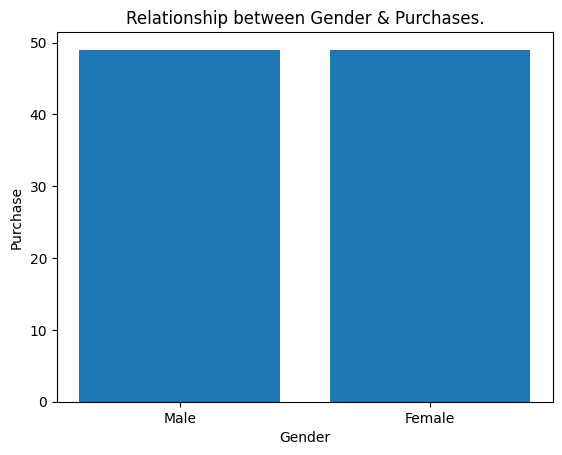

C:\Users\Admin\AppData\Local\Temp\ipykernel_5580\2484487007.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([income_churn_0, income_churn_1], labels=["No Churn", "Churn"])


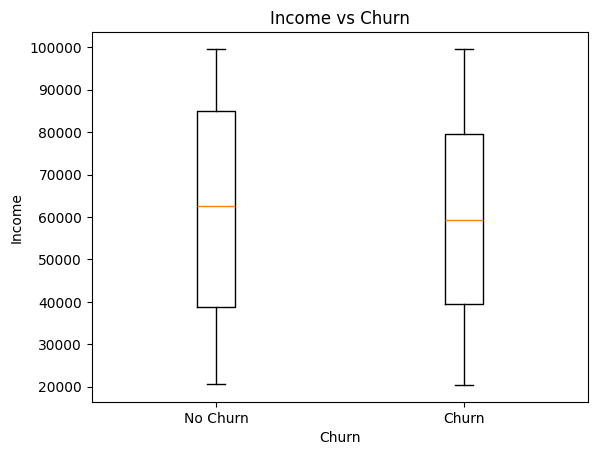

In [53]:
#Customer_ID  Income  Purchases  Age  Gender  Tenure  Churn  App_Usage_Hours

#Bivariate Analysis

#Bar chart for Gender & Purchases.
plt.bar(x=df["Gender"], height=df["Purchases"])
plt.title("Relationship between Gender & Purchases.")
plt.xlabel("Gender")
plt.ylabel("Purchase")
plt.show()

#Boxplot for Income & Churn.
income_churn_0 = df[df["Churn"] == 0]["Income"]
income_churn_1 = df[df["Churn"] == 1]["Income"]

plt.boxplot([income_churn_0, income_churn_1], labels=["No Churn", "Churn"])
plt.title("Income vs Churn")
plt.xlabel("Churn")
plt.ylabel("Income")
plt.show()

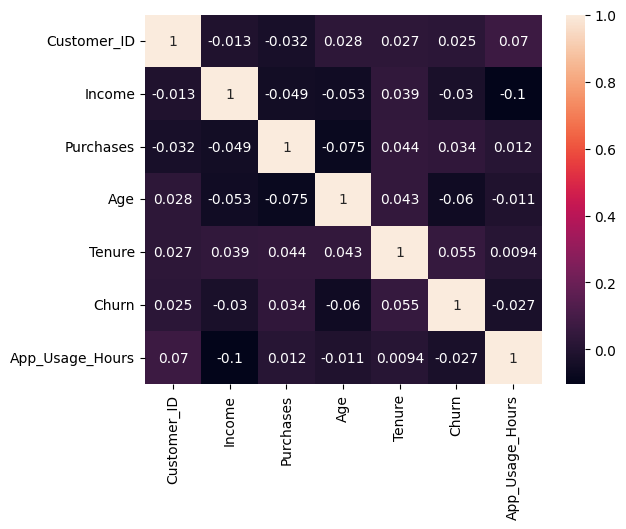

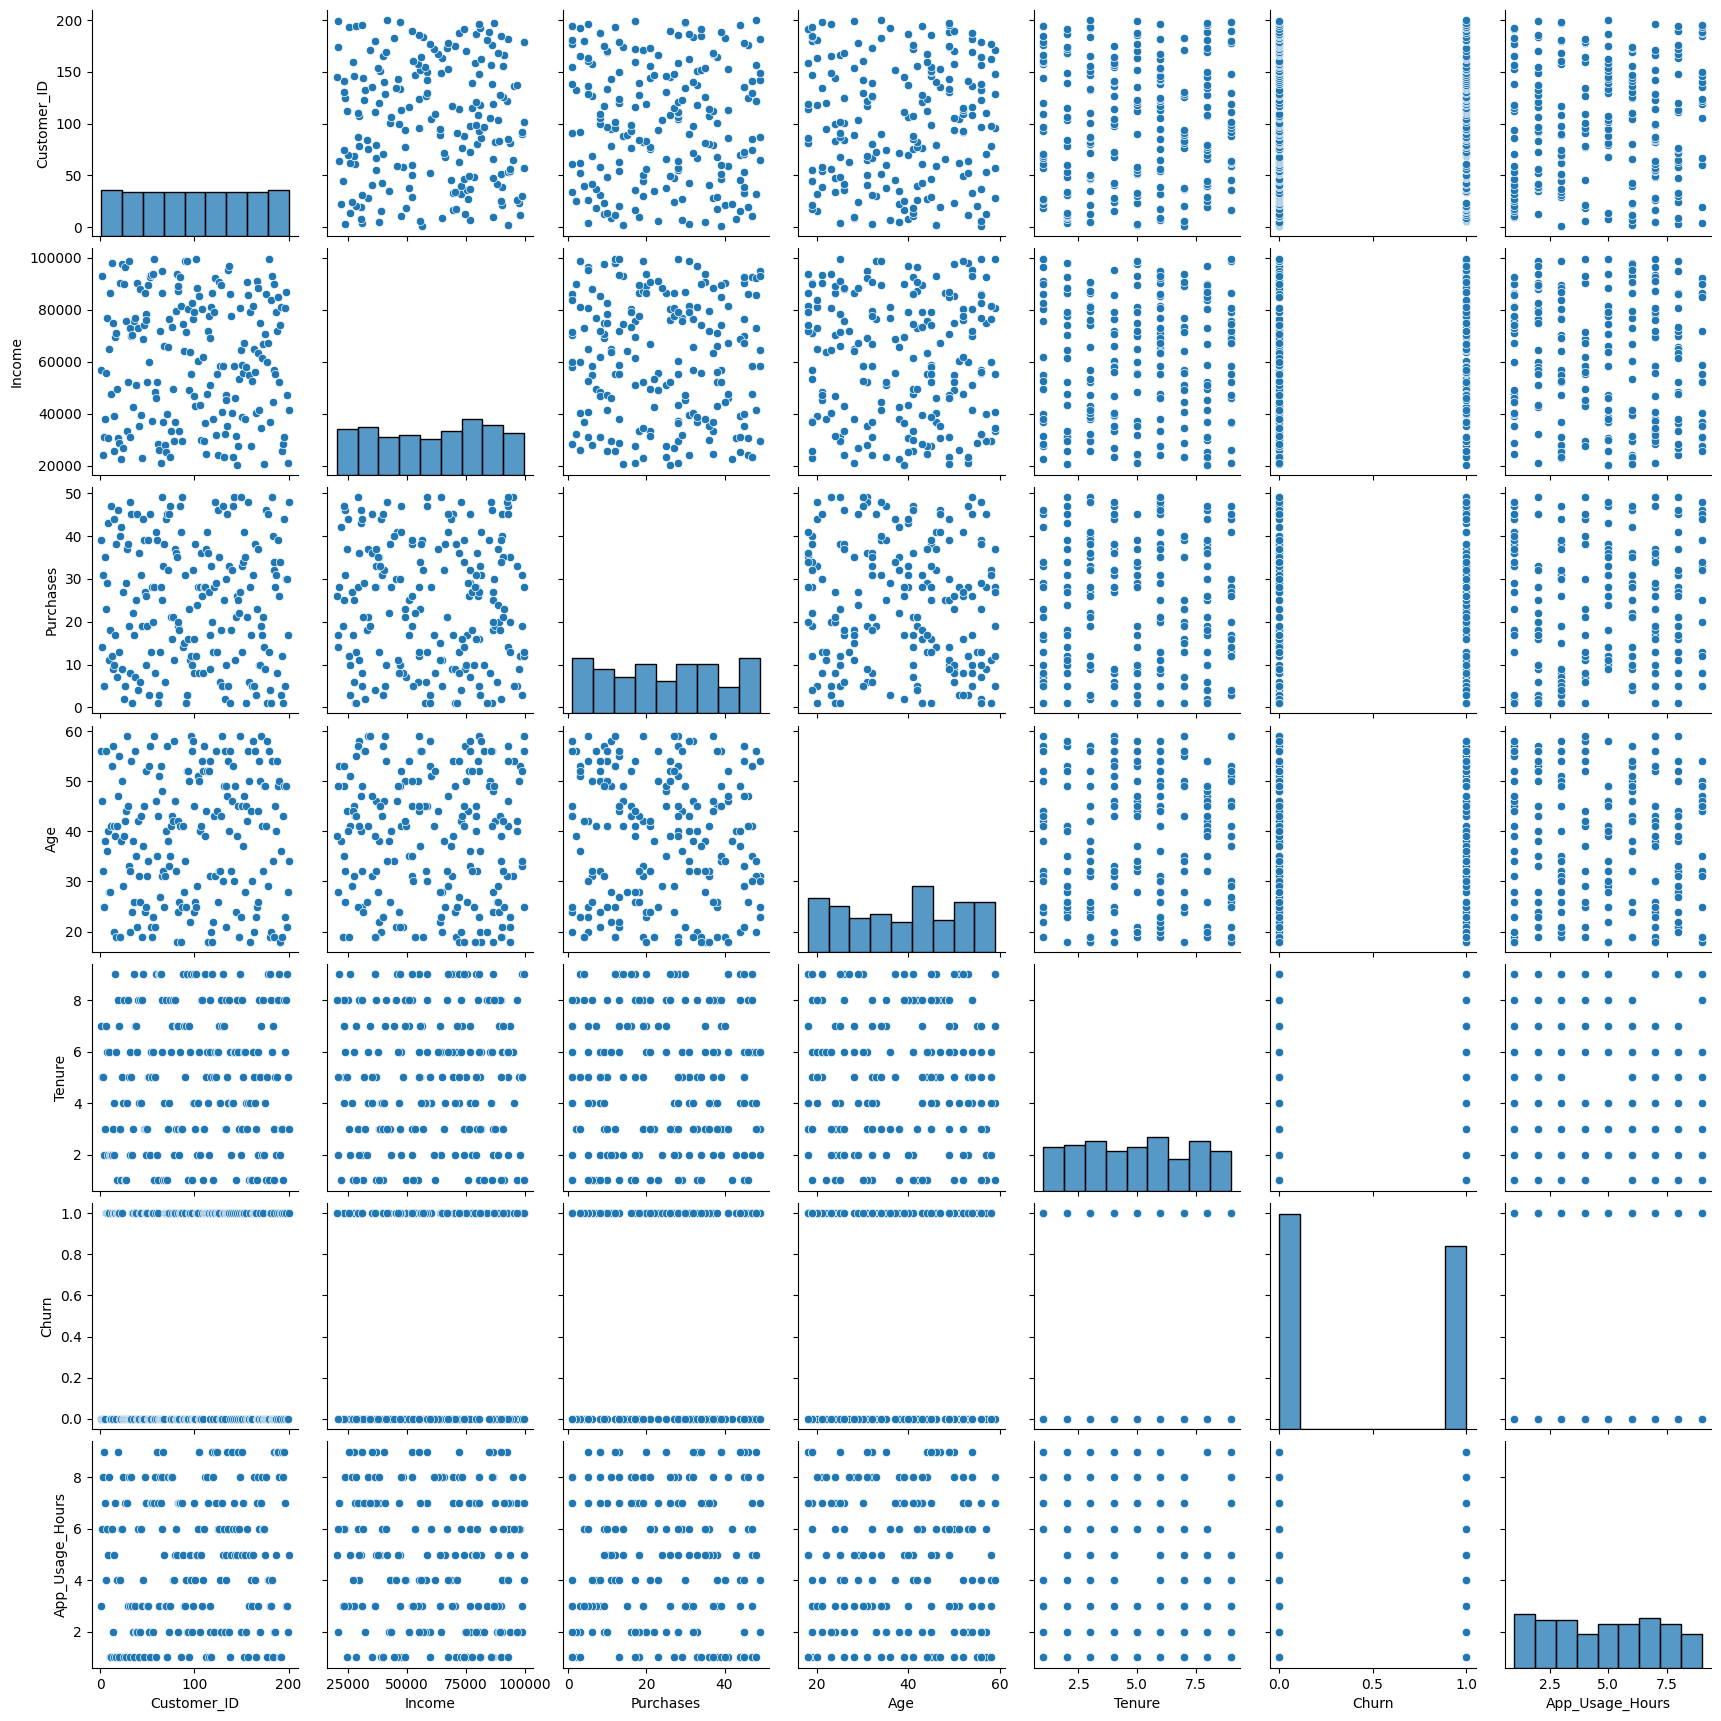

In [58]:
#collected all numeric colums 
numeric_df=df.select_dtypes(include="number")

import seaborn as sns

#Heatmap 
corr=numeric_df.corr()
sns.heatmap(corr,annot=True)

#pairplot
sns.pairplot(df)

Part E: Data Profiling

11. Generate a Pandas Profiling Report that summarizes:

• Missing values.
• Descriptive statistics.
• Correlations.
Warnings on potential data quality issues.

In [5]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Customer Data Profiling Report", explorative=True)

profile.to_file("report.html")

NameError: name 'df' is not defined